In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

from likelihood_ratios import calc_likelihood_ratios

In [2]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

In [3]:
from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler((0, 1))

# Gram Positive

In [4]:
gp_results = pd.read_csv(
    "gp_bootstrap_results_df.csv",
    #sep="\t",
)

#gp_results[bootstrap_columns] = scaler.fit_transform(gp_results[bootstrap_columns])


In [5]:
#gp_results = gp_results[gp_results['Bacteremia Rate'] > 0.5]

In [6]:
gp_results['gram_positive'].value_counts()

gram_positive
0    235
1     18
Name: count, dtype: int64

In [7]:

gp_bs_df, gp_lr_df = calc_likelihood_ratios(
    gp_results,
    "gram_positive",
    "Gram Positive",
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    bootstrap_columns,
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Doc

In [8]:
gn_results = pd.read_csv(
    "gn_bootstrap_results_df.csv",
    #sep="\t",
)

#gn_results[bootstrap_columns] = scaler.fit_transform(gn_results[bootstrap_columns])

#gn_results = gn_results[gn_results['Bacteremia Rate'] > 0.0]

gn_bs_df, gn_lr_df = calc_likelihood_ratios(
    gn_results,
    "gram_negative",
    "Gram Negative",
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
    bootstrap_columns,
)

In [9]:
lr_combined = pd.concat(
    [gp_lr_df, gn_lr_df],
    ignore_index=True,
)

recall_auc_combined = pd.concat(
    [gp_bs_df, gn_bs_df],
    ignore_index=True,
)

In [10]:
gp_results

,Unnamed: 0,target_bootstrap_0,target_bootstrap_1,target_bootstrap_2,target_bootstrap_3,target_bootstrap_4,target_bootstrap_5,target_bootstrap_6,target_bootstrap_7,target_bootstrap_8,...,lower_resp,ecoli,gram_positive,gram_negative,strep,enteroc,Bacteremia Rate,Lower Resp Rate,Gram Pos Rate,Gram Neg Rate
0,0,0.3,0.3,0.4,0.4,0.3,0.3,0.3,0.3,0.4,...,0,0,0,0,0,0,0.7004,0.0900,0.3592,0.2423
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.3536,0.0256,0.0000,0.2047
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,0,0.3687,0.1866,0.0001,0.1927
3,3,0.0,0.0,0.1,0.0,0.1,0.0,0.1,0.1,0.1,...,0,0,0,0,0,0,0.0897,0.1010,0.0891,0.0000
4,4,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,...,0,0,0,0,0,0,0.1887,0.0893,0.0106,0.0893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,248,0.1,0.2,0.1,0.2,0.2,0.2,0.2,0.3,0.2,...,0,0,0,0,0,0,0.2444,0.2384,0.1537,0.0000
249,249,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0902,0.0000,0.0000,0.0000
250,250,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0,0,0,0,0,0,0.9106,0.0907,0.0907,0.6441
251,251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,0,0.4252,0.0000,0.0028,0.1531


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_71112/3420821112.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_71112/3420821112.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[3].set_xticklabels(


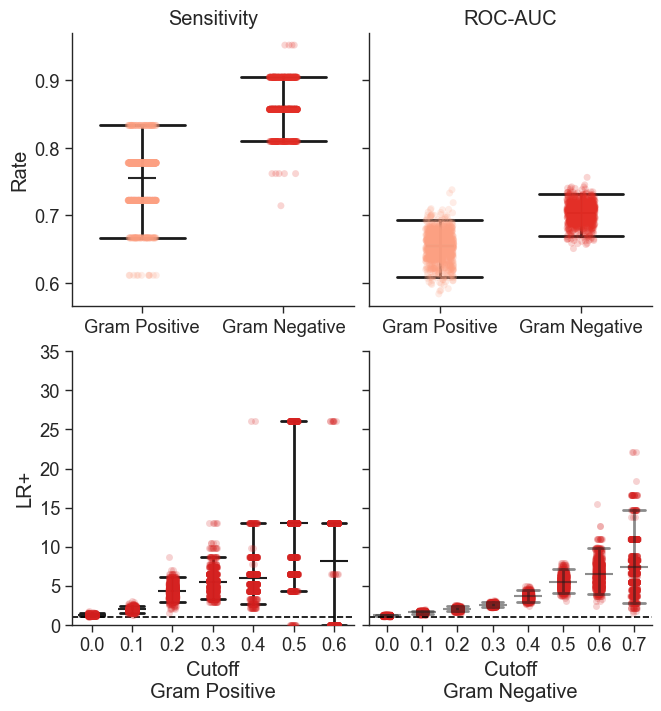

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    constrained_layout=True,
    sharey="row",
)

axs = axs.ravel()

sns.pointplot(
    data=recall_auc_combined,
    x="Label",
    y="Recall",
    hue="Label",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[0]
)

sns.stripplot(
    data=recall_auc_combined,
    x="Label",
    y="Recall",
    hue="Label",
    ax=axs[0],
    palette="Reds",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

axs[0].set_xlabel("")


sns.pointplot(
    data=recall_auc_combined,
    x="Label",
    y="AUC",
    hue="Label",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[1]
)

sns.stripplot(
    data=recall_auc_combined,
    x="Label",
    y="AUC",
    hue="Label",
    ax=axs[1],
    palette="Reds",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

axs[1].set_xlabel("")



sns.pointplot(
    data=gp_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[2]
)

sns.stripplot(
    data=gp_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[2],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

axs[2].set_xlabel("Cutoff\nGram Positive")

axs[2].axhline(y=1, linestyle='--', color='black')
axs[2].set_xticklabels(
    [f"{val:.1f}" for val in gp_lr_df['Cutoff']],
)

sns.pointplot(
    data=gn_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[3],
    alpha=0.5,
)

sns.stripplot(
    data=gn_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[3],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1
)

axs[3].set_xlabel("Cutoff\nGram Negative")

# axs[3].sharey(axs[2])
# axs[3].set_ylabel("")
# #axs[3].set_yticklabels([])
axs[2].set_ylim(0,35)

axs[3].axhline(y=1, linestyle='--', color='black')
axs[3].set_xticklabels(
    [f"{val:.1f}" for val in gn_lr_df['Cutoff']],
)

fig.set_size_inches(
    (6.5, 7)
)

axs[0].set_ylabel("Rate")

axs[0].set_title("Sensitivity")
axs[1].set_title("ROC-AUC")

fig.savefig(
    "infection_metrics.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)


In [12]:
lr_results = pd.read_csv(
    "lower_resp_bootstrap_results_df.csv",
    #sep="\t",
)

lr_bs_df, lr_lr_df = calc_likelihood_ratios(
    lr_results,
    "lower_resp",
    "Lower Respiratory",
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    bootstrap_columns,
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Doc

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_71112/2311499172.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(


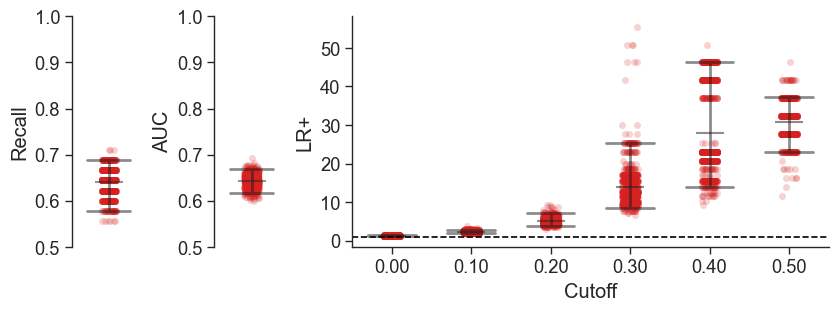

In [13]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    width_ratios=[0.15, 0.15, 1],
    constrained_layout=True,
    #sharey="row",
)

axs = axs.ravel()

sns.pointplot(
    data=lr_bs_df,
    x="Label",
    y="Recall",
    hue="Label",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[0],
    alpha=0.5,
)

sns.stripplot(
    data=lr_bs_df,
    x="Label",
    y="Recall",
    #hue="Label",
    ax=axs[0],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1

)

axs[0].set_xlabel("")


sns.pointplot(
    data=lr_bs_df,
    x="Label",
    y="AUC",
    hue="Label",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[1],
    alpha=0.5,
)

sns.stripplot(
    data=lr_bs_df,
    x="Label",
    y="AUC",
    #hue="Label",
    ax=axs[1],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1
)

axs[1].set_xlabel("")


sns.pointplot(
    data=lr_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[2],
    alpha=0.5,
)

sns.stripplot(
    data=lr_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[2],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1

)

axs[2].set_xlabel("Cutoff")

axs[2].axhline(y=1, linestyle='--', color='black')
axs[2].set_xticklabels(
    [f"{val:.2f}" for val in gp_lr_df['Cutoff']],
)


#axs[3].set_xlabel("Cutoff\nGram Negative")

# axs[3].sharey(axs[2])
# axs[3].set_ylabel("")
# #axs[3].set_yticklabels([])
# axs[2].set_ylim(0, 25)

# axs[3].axhline(y=1, linestyle='--', color='black')
# axs[3].set_xticklabels(
#     [f"{val:.2f}" for val in gn_lr_df['Cutoff']],
# )

fig.set_size_inches(
    (8.27, 3)
)


axs[0].set_xlabel("")
axs[1].set_xlabel("")
axs[0].set_xticklabels([])
axs[0].set_xticks([])
axs[1].set_xticklabels([])
axs[1].set_xticks([])

axs[0].set_ylim([0.5, 1.0])
axs[1].sharey(axs[0])

sns.despine(ax=axs[0], bottom=True, top=True, trim=True, offset=1)
sns.despine(ax=axs[1], bottom=True, top=True, trim=True, offset=1)

fig.savefig(
    "lower_resp_lrs.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [14]:
lr_bs_df[["Recall", "AUC", "Label"]].groupby("Label").mean()

,Recall,AUC
Label,,
Lower Respiratory,0.641556,0.643494


In [15]:
recall_auc_combined[["Recall", "AUC", "Label"]].groupby("Label").mean()

,Recall,AUC
Label,,
Gram Negative,0.861333,0.703680
Gram Positive,0.754722,0.654405
